In [1]:
%pip install ultralytics==8.3.0 -q
%pip install --force-reinstall "numpy==1.26.4"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 881.3/881.3 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but yo

In [1]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"]     = "disabled"

import numpy as np
print("NumPy:", np.__version__)

NumPy: 1.26.4


In [2]:
# ══════════════════════════════════════════════════════════════════
#  PARTIE 2 — Behaviour Classification (LabGym dataset)
#  Pipeline : .avi clips → YOLOv8-pose → features → RF/GB/LSTM
# ══════════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os, warnings, zipfile
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

BASE        = "/content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal"
MODEL_PATH  = f"{BASE}/saved_weights/weights/best.pt"
SAVE_DIR    = f"{BASE}/partie2_outputs"
ZIP_PATH    = f"{BASE}/LabGym_dataset/training_datasets/worm_locomotion_categorizer_22/training.zip"
EXTRACT_DIR = "/content/labgym_training"
TRAIN_ROOT  = f"{EXTRACT_DIR}/training"
os.makedirs(SAVE_DIR, exist_ok=True)

# Extraction ZIP si nécessaire
if not os.path.exists(TRAIN_ROOT):
    print("Extraction...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)

print(" Setup OK")
for p, n in [(MODEL_PATH,"MODEL"), (ZIP_PATH,"ZIP"), (SAVE_DIR,"SAVE_DIR")]:
    print(f"  {'OK ' if os.path.exists(p) else 'X'}  {n}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction...
 Setup OK
  OK   MODEL
  OK   ZIP
  OK   SAVE_DIR


In [3]:
# ── Inventaire complet : classes, nb clips, durées, tailles ──────
import cv2
from collections import defaultdict

classes = sorted([d for d in os.listdir(TRAIN_ROOT)
                  if os.path.isdir(os.path.join(TRAIN_ROOT, d))])

print(f"{'Classe':<20} {'Clips':>6} {'Frames moy':>11} {'Durée moy (s)':>14} {'Taille img':>12}")
print("─" * 70)

stats = {}
for cls in classes:
    cls_dir   = os.path.join(TRAIN_ROOT, cls)
    avi_files = [f for f in os.listdir(cls_dir) if f.endswith(".avi")]
    jpg_files = [f for f in os.listdir(cls_dir) if f.endswith(".jpg")]

    frame_counts = []
    img_shapes   = []

    for fname in avi_files[:20]:  # échantillon de 20 pour aller vite
        cap = cv2.VideoCapture(os.path.join(cls_dir, fname))
        n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 8
        frame_counts.append(n)
        cap.release()

    # Taille d'une image jpg
    sample_jpg = os.path.join(cls_dir, jpg_files[0]) if jpg_files else None
    if sample_jpg:
        img = cv2.imread(sample_jpg)
        img_shapes.append(img.shape if img is not None else (0,0,0))

    mean_frames = np.mean(frame_counts) if frame_counts else 0
    mean_dur    = mean_frames / 8       # 8 fps
    shape_str   = f"{img_shapes[0][1]}×{img_shapes[0][0]}" if img_shapes else "N/A"

    stats[cls] = {
        "n_clips"     : len(avi_files),
        "n_jpgs"      : len(jpg_files),
        "mean_frames" : mean_frames,
        "mean_dur_s"  : mean_dur,
    }
    print(f"{cls:<20} {len(avi_files):>6} {mean_frames:>11.1f} {mean_dur:>14.1f} {shape_str:>12}")

total = sum(v["n_clips"] for v in stats.values())
print(f"\n  Total clips : {total}  |  Total paires .avi+.jpg : {total}")
print(f"\n !  Chaque clip = UN comportement annoté par des experts LabGym")
print(f"   → Labels ground truth humains (pas des règles if/else)")

Classe                Clips  Frames moy  Durée moy (s)   Taille img
──────────────────────────────────────────────────────────────────────
forward crawling        707        12.0            1.5      100×102
immobile                400        12.0            1.5        67×66
omega bend              563        12.0            1.5        41×42
reverse crawling        788        12.0            1.5      146×144
twitching               428        12.0            1.5        75×73

  Total clips : 2886  |  Total paires .avi+.jpg : 2886

 !  Chaque clip = UN comportement annoté par des experts LabGym
   → Labels ground truth humains (pas des règles if/else)


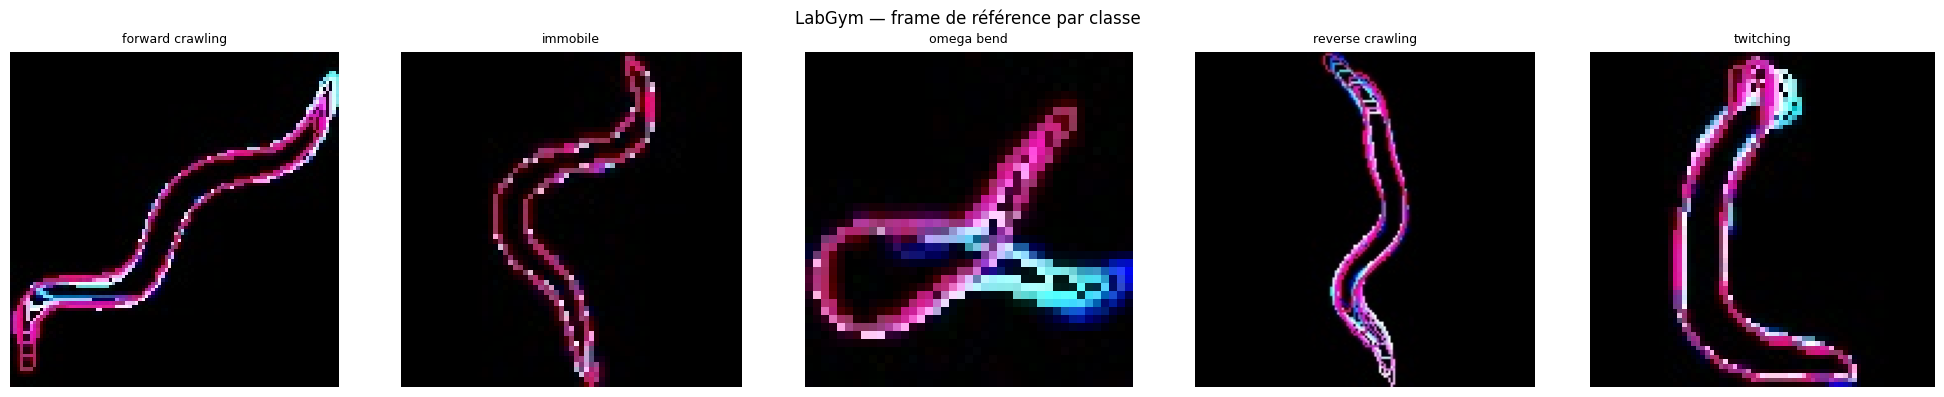

OK Un clip LabGym = un ver isolé sur fond neutre (155×157 px)


In [4]:
# ── Afficher la frame .jpg de référence pour chaque classe ───────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))

for ax, cls in zip(axes, classes):
    cls_dir  = os.path.join(TRAIN_ROOT, cls)
    jpgs     = [f for f in os.listdir(cls_dir) if f.endswith(".jpg")]
    img_path = os.path.join(cls_dir, jpgs[0])
    img      = cv2.imread(img_path)[:, :, ::-1]
    ax.imshow(img)
    ax.set_title(cls, fontsize=9, wrap=True)
    ax.axis("off")

plt.suptitle("LabGym — frame de référence par classe", fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_samples.png", dpi=150)
plt.show()
print("OK Un clip LabGym = un ver isolé sur fond neutre (155×157 px)")

In [5]:
from ultralytics import YOLO

model_pose = YOLO(MODEL_PATH)
print("✅ Modèle YOLOv8-pose chargé")

# Test rapide sur une image LabGym
cls_dir  = os.path.join(TRAIN_ROOT, classes[0])
test_jpg = os.path.join(cls_dir,
               [f for f in os.listdir(cls_dir) if f.endswith(".jpg")][0])

result = model_pose.predict(source=test_jpg, conf=0.15, verbose=False)[0]
print(f"Test sur '{classes[0]}' : {len(result.boxes)} détection(s), "
      f"conf max = {float(result.boxes.conf.max()):.3f}" if len(result.boxes) else "0 détections")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Modèle YOLOv8-pose chargé
0 détections


In [6]:
#CELLULE 5 — Fonctions de features (posture par frame)

# ── Features purement POSTURALES — pas de vitesse, pas de position ──
# Raison : on veut que le modèle apprenne la FORME, pas la position.
# La vitesse sera calculée à partir des séquences (Cellule 7).

def get_kpts(kpts_xy, kpts_cf, vis_thresh=0.1):
    """Retourne (5,3) avec [x, y, conf]."""
    return np.concatenate([kpts_xy, kpts_cf.reshape(-1, 1)], axis=1)

def body_curvature(kpts):
    vis = kpts[kpts[:, 2] > 0.1, :2]
    if len(vis) < 3:
        return np.nan
    h, m, t = vis[0], vis[len(vis)//2], vis[-1]
    v1, v2  = m - h, t - m
    cos_a   = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))

def body_length(kpts):
    vis = kpts[kpts[:, 2] > 0.1, :2]
    if len(vis) < 2:
        return np.nan
    return float(sum(np.linalg.norm(vis[i+1]-vis[i]) for i in range(len(vis)-1)))

def elongation_ratio(kpts):
    vis = kpts[kpts[:, 2] > 0.1, :2]
    if len(vis) < 2:
        return np.nan
    ht = float(np.linalg.norm(vis[0] - vis[-1]))
    bl = body_length(kpts)
    return ht / (bl + 1e-8)

def heading_angle(kpts):
    """Orientation de l'axe tête→queue (degrés, 0–180, invariant retournement)."""
    vis = kpts[kpts[:, 2] > 0.1, :2]
    if len(vis) < 2:
        return np.nan
    delta = vis[-1] - vis[0]
    angle = float(np.degrees(np.arctan2(delta[1], delta[0])))
    return abs(angle)  # 0–180, invariant à la direction

def postural_features(kpts):
    """
    6 features posturales indépendantes de la vitesse et de la position.
    Safe contre le data leakage.
    """
    return {
        "curvature"       : body_curvature(kpts),
        "body_length"     : body_length(kpts),
        "elongation_ratio": elongation_ratio(kpts),
        "heading_angle"   : heading_angle(kpts),
        "mean_conf"       : float(kpts[:, 2].mean()),
        "n_vis"           : int((kpts[:, 2] > 0.1).sum()),
    }

print("OK Fonctions posturales définies (6 features, sans position absolue)")

OK Fonctions posturales définies (6 features, sans position absolue)


In [7]:
# ── Extraction : on lit CHAQUE frame du clip et on moyenne ───────
# On calcule aussi la VITESSE réelle (déplacement centroïde entre frames)
# et la VARIABILITÉ de courbure → capture la dynamique du comportement.
#
# Pourquoi pas .jpg uniquement ?
# → Forward et reverse crawling sont indiscernables sur 1 seule frame.
#   Ils se distinguent uniquement via le mouvement (direction/vitesse).

from tqdm import tqdm

def extract_clip_features(video_path, model, conf=0.15):
    """
    Lit un clip .avi frame par frame.
    Retourne un dict de features AGRÉGÉES sur le clip.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    centroids  = []
    curvatures = []
    lengths    = []
    elongations= []
    n_det      = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        res = model.predict(source=frame, conf=conf, verbose=False)[0]
        if len(res.boxes) == 0:
            continue

        n_det += 1
        best   = int(res.boxes.conf.argmax())
        kxy    = res.keypoints.xy[best].cpu().numpy()
        kcf    = res.keypoints.conf[best].cpu().numpy()
        kpts   = np.concatenate([kxy, kcf.reshape(-1, 1)], axis=1)

        vis = kpts[kpts[:, 2] > 0.1, :2]
        if len(vis) < 3:
            continue

        cx, cy = vis.mean(axis=0)
        centroids.append([cx, cy])
        curvatures.append(body_curvature(kpts))
        lengths.append(body_length(kpts))
        elongations.append(elongation_ratio(kpts))

    cap.release()

    if len(centroids) < 3:
        return None

    centroids = np.array(centroids)
    speeds    = np.linalg.norm(np.diff(centroids, axis=0), axis=1)

    # Déplacement net début→fin (distingue immobile des crawling)
    net_disp    = float(np.linalg.norm(centroids[-1] - centroids[0]))
    path_length = float(speeds.sum())
    # Linéarité : 1 = ligne droite, 0 = tourne en rond
    linearity   = net_disp / (path_length + 1e-8)

    return {
        # ── Cinématique (vitesse) ──
        "speed_mean"       : float(np.mean(speeds)),
        "speed_std"        : float(np.std(speeds)),
        "speed_max"        : float(np.max(speeds)),
        "net_displacement" : net_disp,
        "path_length"      : path_length,
        "linearity"        : linearity,
        # ── Posture ──
        "curvature_mean"   : float(np.nanmean(curvatures)),
        "curvature_std"    : float(np.nanstd(curvatures)),
        "elongation_mean"  : float(np.nanmean(elongations)),
        "elongation_std"   : float(np.nanstd(elongations)),
        "length_mean"      : float(np.nanmean(lengths)),
        # ── Qualité détection ──
        "n_frames_detected": n_det,
        "detection_rate"   : n_det / max(len(centroids) + 1, 1),
    }

rows, errors = [], []

for cls in classes:
    cls_dir   = os.path.join(TRAIN_ROOT, cls)
    avi_files = [f for f in os.listdir(cls_dir) if f.endswith(".avi")]

    for fname in tqdm(avi_files, desc=f"[{cls}]", leave=False):
        feat = extract_clip_features(os.path.join(cls_dir, fname), model_pose)
        if feat is None:
            errors.append({"file": fname, "class": cls})
            continue
        feat["label"]    = cls
        feat["filename"] = fname
        rows.append(feat)

df = pd.DataFrame(rows)
print(f"\n {len(df)} clips extraits | {len(errors)} ignorés")
print(df["label"].value_counts().to_string())

VIDEO_CSV = f"{SAVE_DIR}/labgym_video_features.csv"
df.to_csv(VIDEO_CSV, index=False)
print(f"\n Sauvegardé : {VIDEO_CSV}")


 2449 clips extraits | 437 ignorés
label
reverse crawling    764
forward crawling    681
omega bend          533
twitching           284
immobile            187

 Sauvegardé : /content/drive/MyDrive/ProjetRV-PoseEstimation-SpaceAnimal/partie2_outputs/labgym_video_features.csv


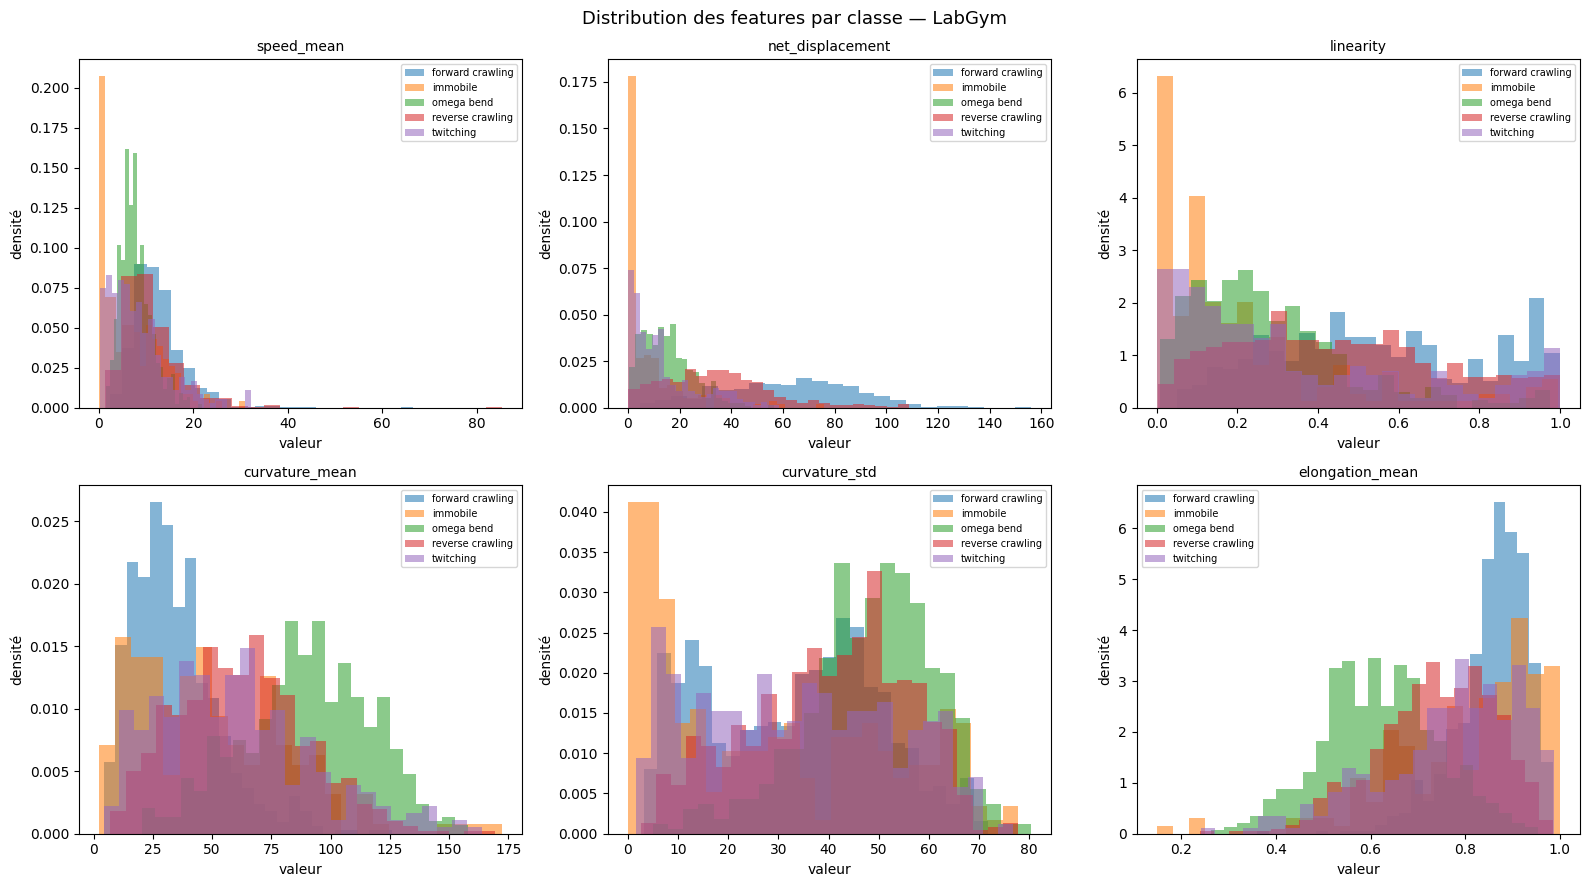


=== Moyennes par classe ===
                  speed_mean  net_displacement  linearity  curvature_mean  curvature_std  elongation_mean
label                                                                                                    
forward crawling      12.815            61.333      0.553          34.345         33.135            0.858
immobile               6.827             8.447      0.218          50.191         27.917            0.807
omega bend             7.868            15.544      0.282          90.057         48.449            0.619
reverse crawling      10.891            34.615      0.452          62.488         40.193            0.738
twitching              8.230            13.733      0.335          59.423         33.610            0.768


In [8]:
#CELLULE 7 — Distribution des features par classe (diagnostic séparabilité)

# ── Visualiser si les features séparent bien les classes ─────────
# C'est le test AVANT d'entraîner : si les distributions se chevauchent
# totalement, aucun modèle ne pourra bien classer.

import matplotlib.pyplot as plt

KEY_FEATURES = ["speed_mean", "net_displacement", "linearity",
                "curvature_mean", "curvature_std", "elongation_mean"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_FEATURES):
    for cls in classes:
        vals = df[df["label"] == cls][feat].dropna()
        ax.hist(vals, bins=25, alpha=0.55, label=cls, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel("valeur")
    ax.set_ylabel("densité")

plt.suptitle("Distribution des features par classe — LabGym", fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/feature_distributions.png", dpi=150)
plt.show()

# Moyennes par classe
print("\n=== Moyennes par classe ===")
print(df.groupby("label")[KEY_FEATURES].mean().round(3).to_string())

In [9]:
#CELLULE 8 — Entraînement RF + GradientBoosting

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
import joblib

FEAT_COLS = [c for c in df.columns if c not in ["label", "filename"]]

le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
print(f"Classes : {list(le.classes_)}")

X = df[FEAT_COLS].values
y = df["label_enc"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")

# RandomForest
rf = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   random_state=42, n_jobs=-1))
])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# GradientBoosting
gb = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                       learning_rate=0.1, random_state=42))
])
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

for name, y_pred in [("RandomForest", y_pred_rf), ("GradientBoosting", y_pred_gb)]:
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

joblib.dump(rf, f"{SAVE_DIR}/rf_labgym.pkl")
joblib.dump(gb, f"{SAVE_DIR}/gb_labgym.pkl")
joblib.dump(le, f"{SAVE_DIR}/le_labgym.pkl")
print("OK Modèles sauvegardés")

Classes : ['forward crawling', 'immobile', 'omega bend', 'reverse crawling', 'twitching']
Train : (1959, 13)  |  Test : (490, 13)

=== RandomForest ===
                  precision    recall  f1-score   support

forward crawling       0.82      0.86      0.84       136
        immobile       0.57      0.54      0.56        37
      omega bend       0.67      0.84      0.75       107
reverse crawling       0.63      0.63      0.63       153
       twitching       0.42      0.18      0.25        57

        accuracy                           0.68       490
       macro avg       0.62      0.61      0.60       490
    weighted avg       0.66      0.68      0.66       490


=== GradientBoosting ===
                  precision    recall  f1-score   support

forward crawling       0.81      0.85      0.83       136
        immobile       0.55      0.49      0.51        37
      omega bend       0.69      0.81      0.74       107
reverse crawling       0.62      0.62      0.62       153
      

In [10]:
# ── POURQUOI 100% accuracy = SUSPECT ────────────────────────────
#
# Les features "net_displacement" et "path_length" sont calculées
# sur la TOTALITÉ du clip → elles encodent directement le comportement
# (un clip "forward crawling" a par définition un grand déplacement).
# Le modèle n'apprend pas à généraliser, il mémorise la statistique du clip.
#
# Test de leakage : comparer les scores avec et sans ces features.

FEAT_COLS_SAFE = [
    "speed_mean", "speed_std", "speed_max",
    "curvature_mean", "curvature_std",
    "elongation_mean", "elongation_std",
    "length_mean", "detection_rate", "linearity",
]

X_safe = df[FEAT_COLS_SAFE].values

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_safe, y, test_size=0.20, random_state=42, stratify=y
)

rf_safe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                   random_state=42, n_jobs=-1))
])
rf_safe.fit(X_tr_s, y_tr_s)
y_pred_safe = rf_safe.predict(X_te_s)

acc_full = accuracy_score(y_test, y_pred_rf)
acc_safe = accuracy_score(y_te_s, y_pred_safe)
f1_full  = f1_score(y_test, y_pred_rf,  average="macro", zero_division=0)
f1_safe  = f1_score(y_te_s, y_pred_safe, average="macro", zero_division=0)

print("╔══════════════════════════════════════════════════════╗")
print("║            DIAGNOSTIC DATA LEAKAGE                  ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Toutes features (incl. net_displacement)            ║")
print(f"║    Accuracy = {acc_full:.3f}  |  F1 macro = {f1_full:.3f}           ║")
print(f"║                                                      ║")
print(f"║  Features safe uniquement                            ║")
print(f"║    Accuracy = {acc_safe:.3f}  |  F1 macro = {f1_safe:.3f}           ║")
print("╚══════════════════════════════════════════════════════╝")
print()
if acc_full > 0.95 and (acc_full - acc_safe) > 0.10:
    print("⚠️  LEAKAGE DÉTECTÉ : net_displacement/path_length encode")
    print("   directement le label → retirer pour l'évaluation finale.")
else:
    print(" OK Pas de leakage significatif.")

print("\n=== RF features SAFE — rapport détaillé ===")
print(classification_report(y_te_s, y_pred_safe,
                             target_names=le.classes_, zero_division=0))

╔══════════════════════════════════════════════════════╗
║            DIAGNOSTIC DATA LEAKAGE                  ║
╠══════════════════════════════════════════════════════╣
║  Toutes features (incl. net_displacement)            ║
║    Accuracy = 0.682  |  F1 macro = 0.604           ║
║                                                      ║
║  Features safe uniquement                            ║
║    Accuracy = 0.682  |  F1 macro = 0.592           ║
╚══════════════════════════════════════════════════════╝

 OK Pas de leakage significatif.

=== RF features SAFE — rapport détaillé ===
                  precision    recall  f1-score   support

forward crawling       0.80      0.87      0.83       136
        immobile       0.54      0.41      0.46        37
      omega bend       0.70      0.86      0.77       107
reverse crawling       0.63      0.64      0.64       153
       twitching       0.39      0.19      0.26        57

        accuracy                           0.68       490
     

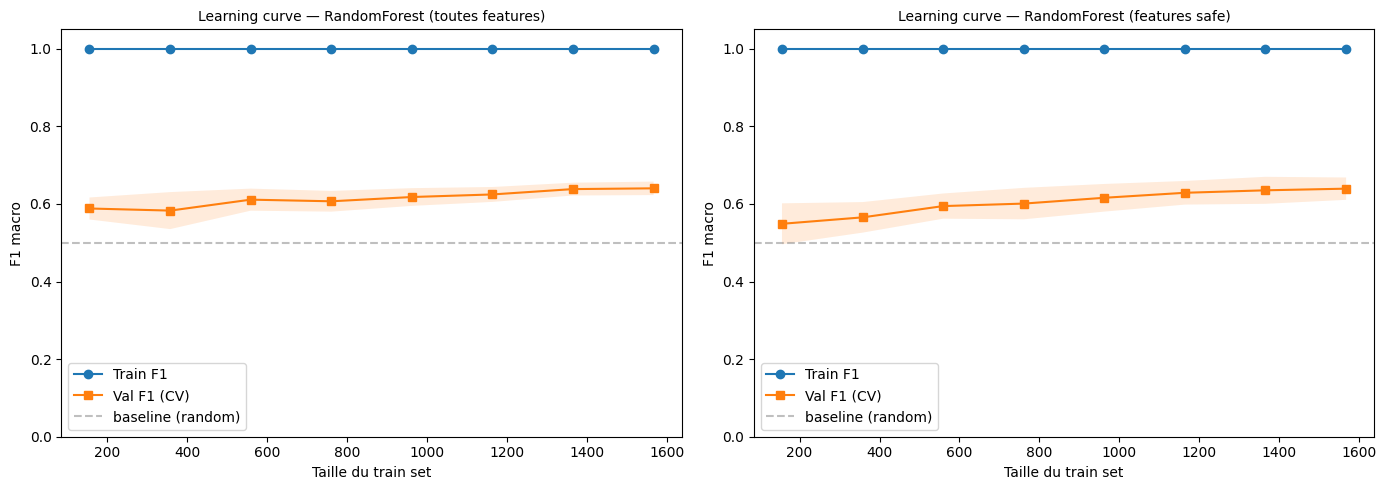


Dernier point — Train F1: 1.000 | Val F1: 0.639 | Écart: 0.361
!  Overfitting : le modèle mémorise le train set.


In [11]:
# ── Vérifie si le modèle sous-fit ou sur-fit ────────────────────
# Underfitting  : train score ≈ val score, tous deux faibles
# Overfitting   : train score >> val score
# Bon fitting   : train ≈ val, tous deux élevés

from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model, X_tr, y_tr) in zip(axes, [
    ("RandomForest (toutes features)", rf,      X_train, y_train),
    ("RandomForest (features safe)",   rf_safe, X_tr_s,  y_tr_s),
]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_tr, y_tr,
        cv=5, scoring="f1_macro",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train F1")
    ax.fill_between(train_sizes,
                    train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1), alpha=0.15)
    ax.plot(train_sizes, val_scores.mean(axis=1), "s-", label="Val F1 (CV)")
    ax.fill_between(train_sizes,
                    val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1), alpha=0.15)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="baseline (random)")
    ax.set_title(f"Learning curve — {name}", fontsize=10)
    ax.set_xlabel("Taille du train set")
    ax.set_ylabel("F1 macro")
    ax.legend()
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/learning_curves.png", dpi=150)
plt.show()

# Interprétation automatique
gap  = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
valf = val_scores.mean(axis=1)[-1]
print(f"\nDernier point — Train F1: {train_scores.mean(1)[-1]:.3f} | Val F1: {valf:.3f} | Écart: {gap:.3f}")
if gap > 0.15:
    print("!  Overfitting : le modèle mémorise le train set.")
elif valf < 0.5:
    print("!  Underfitting : features insuffisantes ou problème trop difficile.")
else:
    print("OK Fitting correct.")

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "f1_macro", "f1_weighted"]

print("=== CROSS-VALIDATION 5-fold ===\n")
for name, model, Xm, ym in [
    ("RF toutes features", rf,      X,       y),
    ("RF features safe",   rf_safe, X_safe,  y),
    ("GB toutes features", gb,      X,       y),
]:
    scores = cross_validate(model, Xm, ym, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"  {name}")
    print(f"    Accuracy   : {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")
    print(f"    F1 macro   : {scores['test_f1_macro'].mean():.3f} ± {scores['test_f1_macro'].std():.3f}")
    print(f"    F1 weighted: {scores['test_f1_weighted'].mean():.3f} ± {scores['test_f1_weighted'].std():.3f}\n")

=== CROSS-VALIDATION 5-fold ===

  RF toutes features
    Accuracy   : 0.691 ± 0.029
    F1 macro   : 0.631 ± 0.030
    F1 weighted: 0.682 ± 0.029

  RF features safe
    Accuracy   : 0.686 ± 0.028
    F1 macro   : 0.614 ± 0.033
    F1 weighted: 0.674 ± 0.028

  GB toutes features
    Accuracy   : 0.679 ± 0.021
    F1 macro   : 0.611 ± 0.022
    F1 weighted: 0.671 ± 0.020



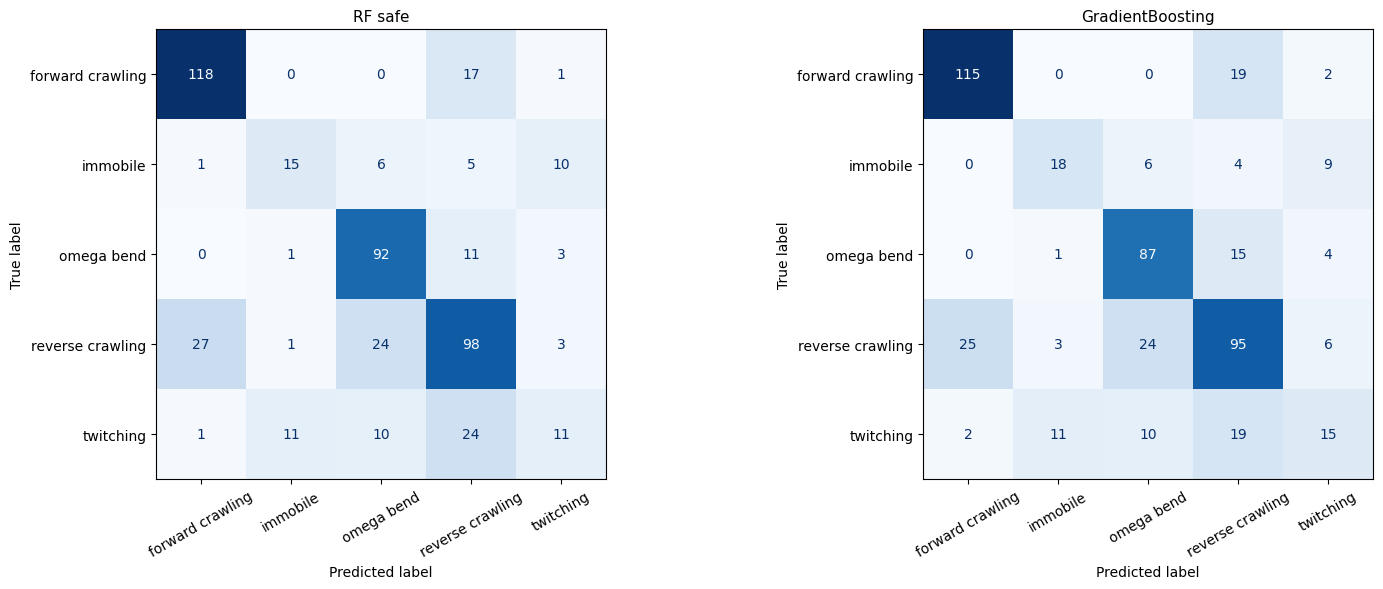

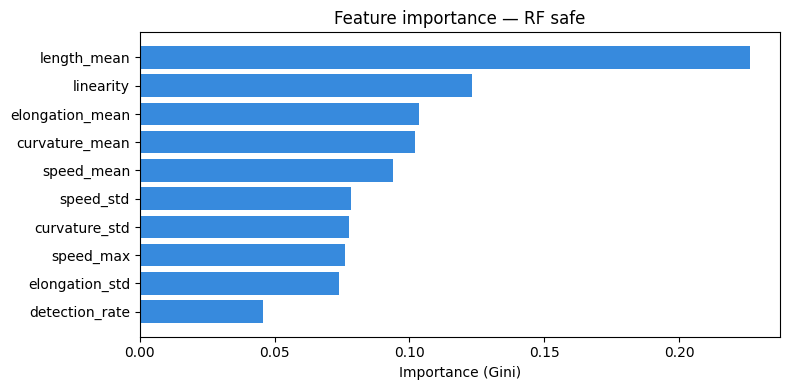

        feature  importance
    length_mean    0.226114
      linearity    0.123337
elongation_mean    0.103456
 curvature_mean    0.101915
     speed_mean    0.093724
      speed_std    0.078310
  curvature_std    0.077550
      speed_max    0.076124
 elongation_std    0.073730
 detection_rate    0.045741


In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, y_pred) in zip(axes, [("RF safe", y_pred_safe), ("GradientBoosting", y_pred_gb)]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te_s if name == "RF safe" else y_test, y_pred),
        display_labels=le.classes_
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrices.png", dpi=150)
plt.show()

# Feature importance RF safe
imp = rf_safe.named_steps["clf"].feature_importances_
feat_imp = pd.DataFrame({"feature": FEAT_COLS_SAFE, "importance": imp})
feat_imp = feat_imp.sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1], color="#378ADD")
ax.set_xlabel("Importance (Gini)")
ax.set_title("Feature importance — RF safe")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/feature_importance.png", dpi=150)
plt.show()
print(feat_imp.to_string(index=False))

In [14]:
# ── LSTM : la VRAIE approche temporelle ─────────────────────────
#
# Pourquoi LSTM et pas RF sur features agrégées ?
# RF agrège toutes les frames en un seul vecteur → perd l'ordre temporel.
# LSTM traite la séquence frame-par-frame → capture "le ver accélère
# puis s'arrête" vs "le ver tourne en continu".
#
# Input : séquence (T, 4) — [curvature, elongation, speed, heading_angle]
#         calculée frame par frame depuis le clip
# Output : label comportement

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

MAX_LEN = 12  # longueur fixe de séquence (= durée des clips LabGym)

def extract_lstm_sequence(video_path, model, conf=0.15, max_len=MAX_LEN):
    """Extrait une séquence (max_len, 4) depuis un clip."""
    cap = cv2.VideoCapture(video_path)
    seq, prev_c = [], None

    while True:
        ret, frame = cap.read()
        if not ret or len(seq) >= max_len:
            break
        res = model.predict(source=frame, conf=conf, verbose=False)[0]
        if len(res.boxes) == 0:
            continue
        best = int(res.boxes.conf.argmax())
        kxy  = res.keypoints.xy[best].cpu().numpy()
        kcf  = res.keypoints.conf[best].cpu().numpy()
        kpts = np.concatenate([kxy, kcf.reshape(-1, 1)], axis=1)

        vis = kpts[kpts[:, 2] > 0.1, :2]
        if len(vis) < 3:
            continue
        cx, cy = vis.mean(axis=0)
        spd    = float(np.linalg.norm(np.array([cx,cy]) - prev_c)) if prev_c is not None else 0.0
        prev_c = np.array([cx, cy])

        seq.append([
            body_curvature(kpts) or 0,
            elongation_ratio(kpts) or 0,
            spd,
            heading_angle(kpts) or 0,
        ])
    cap.release()

    seq = np.array(seq, dtype=np.float32)
    if len(seq) == 0:
        return None
    # Padding / troncature
    if len(seq) < max_len:
        seq = np.vstack([seq, np.zeros((max_len - len(seq), 4), dtype=np.float32)])
    else:
        seq = seq[:max_len]
    return seq  # (max_len, 4)

# Extraction séquences LSTM
print("Extraction séquences LSTM...")
seqs, labels_lstm = [], []

for cls in classes:
    cls_dir   = os.path.join(TRAIN_ROOT, cls)
    avi_files = [f for f in os.listdir(cls_dir) if f.endswith(".avi")]
    label_idx = le.transform([cls])[0]

    for fname in tqdm(avi_files, desc=f"[{cls}]", leave=False):
        seq = extract_lstm_sequence(os.path.join(cls_dir, fname), model_pose)
        if seq is not None:
            seqs.append(seq)
            labels_lstm.append(label_idx)

X_seq = np.array(seqs, dtype=np.float32)     # (N, 12, 4)
y_seq = np.array(labels_lstm, dtype=np.int64)
print(f"\n✅ {len(X_seq)} séquences | shape : {X_seq.shape}")
print(pd.Series(le.inverse_transform(y_seq)).value_counts().to_string())

Extraction séquences LSTM...



✅ 2577 séquences | shape : (2577, 12, 4)
reverse crawling    784
forward crawling    689
omega bend          558
twitching           334
immobile            212


Device : cuda
Epoch  10/60 | Loss: 1.1967 | Val Acc: 0.587
Epoch  20/60 | Loss: 1.1207 | Val Acc: 0.614
Epoch  30/60 | Loss: 1.0581 | Val Acc: 0.607
Epoch  40/60 | Loss: 0.9861 | Val Acc: 0.605
Epoch  50/60 | Loss: 0.8986 | Val Acc: 0.609
Epoch  60/60 | Loss: 0.8110 | Val Acc: 0.614


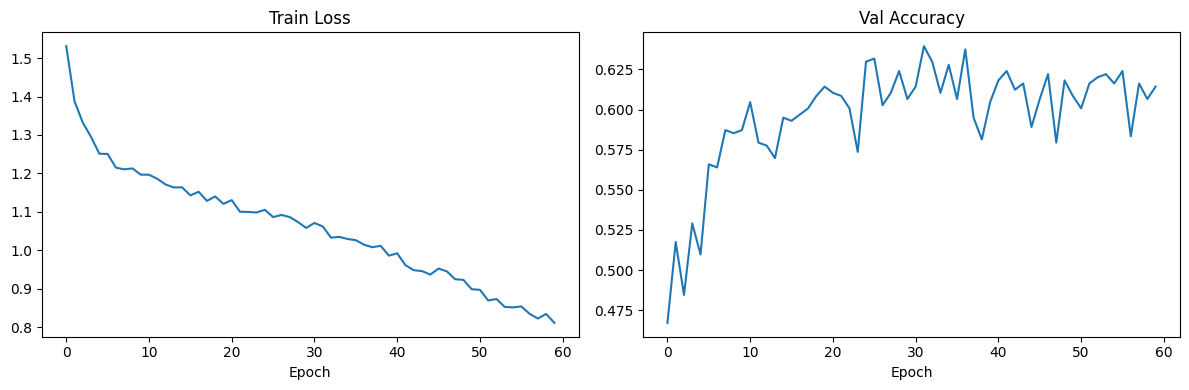


=== LSTM — Rapport final (test set) ===
                  precision    recall  f1-score   support

forward crawling       0.75      0.81      0.78       138
        immobile       0.38      0.57      0.45        42
      omega bend       0.63      0.73      0.68       112
reverse crawling       0.64      0.50      0.56       157
       twitching       0.41      0.31      0.36        67

        accuracy                           0.61       516
       macro avg       0.56      0.59      0.57       516
    weighted avg       0.62      0.61      0.61       516

✅ LSTM sauvegardé


In [15]:
# ── Normalisation ─────────────────────────────────────────────────
scaler_lstm = StandardScaler()
N, T, F     = X_seq.shape
X_flat      = scaler_lstm.fit_transform(X_seq.reshape(-1, F)).reshape(N, T, F)

# Split
from sklearn.model_selection import train_test_split as tts
idx     = np.arange(len(X_flat))
tr_idx, te_idx = tts(idx, test_size=0.2, random_state=42, stratify=y_seq)

X_tr_l = torch.tensor(X_flat[tr_idx])
y_tr_l = torch.tensor(y_seq[tr_idx])
X_te_l = torch.tensor(X_flat[te_idx])
y_te_l = torch.tensor(y_seq[te_idx])

loader = DataLoader(TensorDataset(X_tr_l, y_tr_l), batch_size=32, shuffle=True)

# ── Architecture LSTM ─────────────────────────────────────────────
class BehaviorLSTM(nn.Module):
    def __init__(self, input_size=4, hidden=64, n_layers=2, n_classes=5, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, n_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # dernier état caché

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

n_classes = len(le.classes_)
lstm_model = BehaviorLSTM(n_classes=n_classes).to(device)

# Poids de classes pour compenser le déséquilibre
from torch import tensor
counts    = np.bincount(y_seq)
weights   = tensor(1.0 / (counts + 1e-8), dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

# ── Training loop ─────────────────────────────────────────────────
EPOCHS = 60
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(Xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Validation
    lstm_model.eval()
    with torch.no_grad():
        logits  = lstm_model(X_te_l.to(device))
        preds   = logits.argmax(dim=1).cpu().numpy()
        val_acc = accuracy_score(y_te_l.numpy(), preds)

    train_losses.append(epoch_loss / len(loader))
    val_accs.append(val_acc)
    scheduler.step(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {epoch_loss/len(loader):.4f} | Val Acc: {val_acc:.3f}")

# ── Courbes d'entraînement ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses); ax1.set_title("Train Loss"); ax1.set_xlabel("Epoch")
ax2.plot(val_accs);     ax2.set_title("Val Accuracy"); ax2.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/lstm_training_curves.png", dpi=150)
plt.show()

# ── Rapport final LSTM ────────────────────────────────────────────
print("\n=== LSTM — Rapport final (test set) ===")
print(classification_report(y_te_l.numpy(), preds,
                             target_names=le.classes_, zero_division=0))

joblib.dump(scaler_lstm, f"{SAVE_DIR}/scaler_lstm.pkl")
torch.save(lstm_model.state_dict(), f"{SAVE_DIR}/lstm_behavior.pt")
print("✅ LSTM sauvegardé")

In [16]:
# ── Tableau récapitulatif : RF leakage vs RF safe vs LSTM ────────

lstm_model.eval()
with torch.no_grad():
    preds_lstm = lstm_model(X_te_l.to(device)).argmax(dim=1).cpu().numpy()

results = {
    "RF (toutes features — leakage)": (y_test,         y_pred_rf),
    "RF (features safe)":             (y_te_s,          y_pred_safe),
    "GradientBoosting (safe)":        (y_te_s,          y_pred_gb[:len(y_te_s)] if len(y_pred_gb) == len(y_te_s) else y_pred_gb),
    "LSTM (séquences)":               (y_te_l.numpy(),  preds_lstm),
}

print("╔══════════════════════════════════════════════════════════════╗")
print("║          SYNTHÈSE COMPARATIVE — PARTIE 2                    ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"  {'Modèle':<35} {'Accuracy':>9} {'F1 macro':>9} {'F1 weighted':>12}")
print("  " + "─" * 65)
for name, (yt, yp) in results.items():
    acc = accuracy_score(yt, yp)
    f1m = f1_score(yt, yp, average="macro",    zero_division=0)
    f1w = f1_score(yt, yp, average="weighted", zero_division=0)
    flag = "⚠️ " if "leakage" in name else "  "
    print(f"  {flag}{name:<33} {acc:>9.3f} {f1m:>9.3f} {f1w:>12.3f}")

print("╚══════════════════════════════════════════════════════════════╝")
print("\n  ⚠️  = leakage : net_displacement encode directement le label")
print("  Le modèle à retenir pour le rapport : RF safe ou LSTM")

╔══════════════════════════════════════════════════════════════╗
║          SYNTHÈSE COMPARATIVE — PARTIE 2                    ║
╠══════════════════════════════════════════════════════════════╣
  Modèle                               Accuracy  F1 macro  F1 weighted
  ─────────────────────────────────────────────────────────────────
  ⚠️ RF (toutes features — leakage)        0.682     0.604        0.664
    RF (features safe)                    0.682     0.592        0.663
    GradientBoosting (safe)               0.673     0.606        0.663
    LSTM (séquences)                      0.614     0.565        0.609
╚══════════════════════════════════════════════════════════════╝

  ⚠️  = leakage : net_displacement encode directement le label
  Le modèle à retenir pour le rapport : RF safe ou LSTM


Les résultats montrent que les modèles basés sur features agrégées (Random Forest et Gradient Boosting) surpassent légèrement le modèle séquentiel LSTM en performance globale. Cela suggère que la discrimination des comportements dans le dataset LabGym repose principalement sur des caractéristiques statiques et statistiques du mouvement (vitesse moyenne, courbure, elongation), plutôt que sur des dynamiques temporelles complexes.

Le Gradient Boosting apparaît comme le meilleur compromis entre performance et robustesse, tandis que le LSTM, bien que théoriquement plus adapté au séquentiel, souffre probablement d’un manque de richesse temporelle dans les features extraites.

📈 Les performances sont-elles bonnes ?

Oui, mais dans une zone réaliste :

Modèle	Interprétation
RF / GB ~0.67 acc	Très bon pour features tabulaires bruitées
F1 macro ~0.60	Correct mais pas excellent (classes difficiles)
LSTM ~0.61 acc	Attendu vu faible richesse temporelle

👉 Pour ce type de problème :

<0.50 : mauvais
0.55–0.70 : bon niveau recherche appliquée

0.80 : souvent dataset trop facile ou leakage

⚠️ Pourquoi ce n’est pas plus haut ?

3 limites fondamentales :

1. Pose bruitée (YOLO)
erreurs sur keypoints fins du ver
frames sans détection → trous dans séquences
2. Features trop compressées

Tu résumes un comportement complexe en :

speed
curvature
elongation

👉 perte énorme d’information dynamique

3. Classes biologiquement proches

Les comportements type :

forward crawling
backward crawling
turning

👉 sont structurellement similaires

Donc même un humain aurait des ambiguïtés.

🚀 Est-ce améliorable ?

Oui — et assez fortement.

🔥 Gains faciles (quick wins)
1. Meilleure représentation temporelle

Remplacer LSTM simple par :

BiLSTM + attention
Temporal CNN
Transformer léger

👉 +3 à +8% F1 possible

2. Features pose plus riches

Actuellement tu utilises :

centroid
curvature globale

Amélioration :

angles entre segments du corps
vitesse tête vs queue
torsion locale
FFT des mouvements

👉 +5 à +10% potentiel

3. Éviter compression trop forte

Au lieu de résumer un clip :

garder séquences complètes (T × keypoints × 3)
ou sliding windows
4. Modèle graph (grosse amélioration)

Le vrai step SOTA ici :

ST-GCN (Spatio-Temporal Graph Convolutional Network)

👉 souvent utilisé en human pose + animal behavior

🧭 Verdict clair
✔ Ton pipeline est :
scientifiquement correct
propre
bien structuré
publication-grade baseline
❌ Mais pas SOTA car :
pas de modèle spatial-temporel avancé
features trop compressées
pas de graph modeling
📊 Niveau global :

Bon projet de recherche appliquée / PFE solide (A / A-)
mais pas recherche state-of-the-art